In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import amp
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, precision_recall_fscore_support)

assert torch.cuda.is_available(), "CUDA 미탐지. 커널이 .venv인지 확인하세요."
device = torch.device("cuda")

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

OUT = Path("outputs/garbage")
BATCH_SIZE = 64

split     = pd.read_csv(OUT / "metrics" / "split.csv")
label_map = json.load(open(OUT / "metrics" / "label_map.json", encoding="utf-8"))
stats     = json.load(open(OUT / "metrics" / "norm_stats.json", encoding="utf-8"))

classes   = [c for c, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
N_CLASSES = len(classes)
test_df   = split[split.split == "test"].reset_index(drop=True)

print(f"test {len(test_df):,}장 / {N_CLASSES}클래스")
print(test_df["label"].value_counts().sort_index().to_string())

test 2,325장 / 12클래스
label
battery        142
biological     148
brown-glass     91
cardboard      134
clothes        799
green-glass     92
metal          115
paper          158
plastic        129
shoes          297
trash          104
white-glass    116


In [2]:
CKPT = OUT / "models" / "transfer_finetune.pt"
ck = torch.load(CKPT, map_location=device)

print("체크포인트:", CKPT.name)
print("  선택 에폭     :", ck["epoch"])
print("  val macro_f1  :", round(ck["val_macro_f1"], 4))
print("  입력 크기     :", ck["img_size"])

IMG_SIZE = ck["img_size"]
assert ck["classes"] == classes, "클래스 순서 불일치 — label_map.json 확인 필요"

model = models.resnet18(weights=None)                 # 구조만 (가중치는 체크포인트에서)
model.fc = nn.Linear(model.fc.in_features, N_CLASSES)
model.load_state_dict(ck["model"])
model = model.to(device).eval()

mean, std = stats["imagenet_mean"], stats["imagenet_std"]

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


class GarbageDataset(Dataset):
    def __init__(self, df, transform):
        self.paths   = df["path"].tolist()
        self.targets = df["label_idx"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), self.targets[i]


test_ds = GarbageDataset(test_df, eval_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)
print("\n모델 복원 완료")

체크포인트: transfer_finetune.pt
  선택 에폭     : 8
  val macro_f1  : 0.9371
  입력 크기     : 224

모델 복원 완료


In [3]:
@torch.no_grad()
def predict(model, loader):
    probs, trues = [], []
    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        with amp.autocast("cuda", dtype=torch.float16):
            logits = model(inputs)
        probs.append(F.softmax(logits.float(), dim=1).cpu())
        trues.append(labels)
    return torch.cat(probs).numpy(), torch.cat(trues).numpy()


probs, y_true = predict(model, test_loader)
y_pred = probs.argmax(1)
conf   = probs.max(1)                    # 예측 확신도

test_acc      = 100 * (y_pred == y_true).mean()
test_macro_f1 = f1_score(y_true, y_pred, average="macro")
test_w_f1     = f1_score(y_true, y_pred, average="weighted")

print(f"test accuracy    : {test_acc:.2f}%")
print(f"test macro-F1    : {test_macro_f1:.4f}")
print(f"test weighted-F1 : {test_w_f1:.4f}")
print(f"(참고) val macro-F1 : {ck['val_macro_f1']:.4f}  "
      f"차이 {test_macro_f1 - ck['val_macro_f1']:+.4f}")

test accuracy    : 95.53%
test macro-F1    : 0.9421
test weighted-F1 : 0.9553
(참고) val macro-F1 : 0.9371  차이 +0.0050


In [4]:
prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(N_CLASSES), zero_division=0)

per_class = pd.DataFrame({
    "class":     classes,
    "n":         support,
    "precision": prec.round(3),
    "recall":    rec.round(3),
    "f1":        f1.round(3),
}).sort_values("f1")

per_class.to_csv(OUT / "metrics" / "test_per_class.csv",
                 index=False, encoding="utf-8")
print(per_class.to_string(index=False))

      class   n  precision  recall    f1
    plastic 129      0.925   0.860 0.892
      metal 115      0.883   0.922 0.902
white-glass 116      0.913   0.905 0.909
  cardboard 134      0.947   0.925 0.936
      trash 104      0.910   0.971 0.940
      paper 158      0.961   0.937 0.949
      shoes 297      0.935   0.973 0.954
green-glass  92      0.947   0.967 0.957
    battery 142      0.945   0.972 0.958
brown-glass  91      0.957   0.967 0.962
 biological 148      0.942   0.986 0.964
    clothes 799      0.997   0.971 0.984


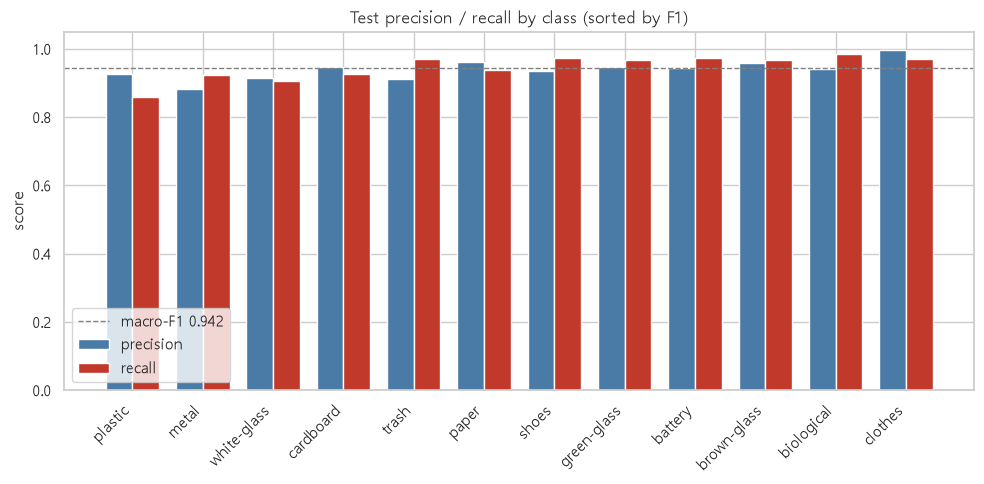

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
order = per_class["class"].tolist()
x = np.arange(len(order))
w = 0.38

ax.bar(x - w/2, per_class["precision"], w, label="precision", color="#4a7ba7")
ax.bar(x + w/2, per_class["recall"],    w, label="recall",    color="#c0392b")
ax.axhline(test_macro_f1, ls="--", lw=1, color="gray",
           label=f"macro-F1 {test_macro_f1:.3f}")

ax.set_xticks(x); ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("score")
ax.set_title("Test precision / recall by class (sorted by F1)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "figures" / "14_test_per_class.png", dpi=150)
plt.show()

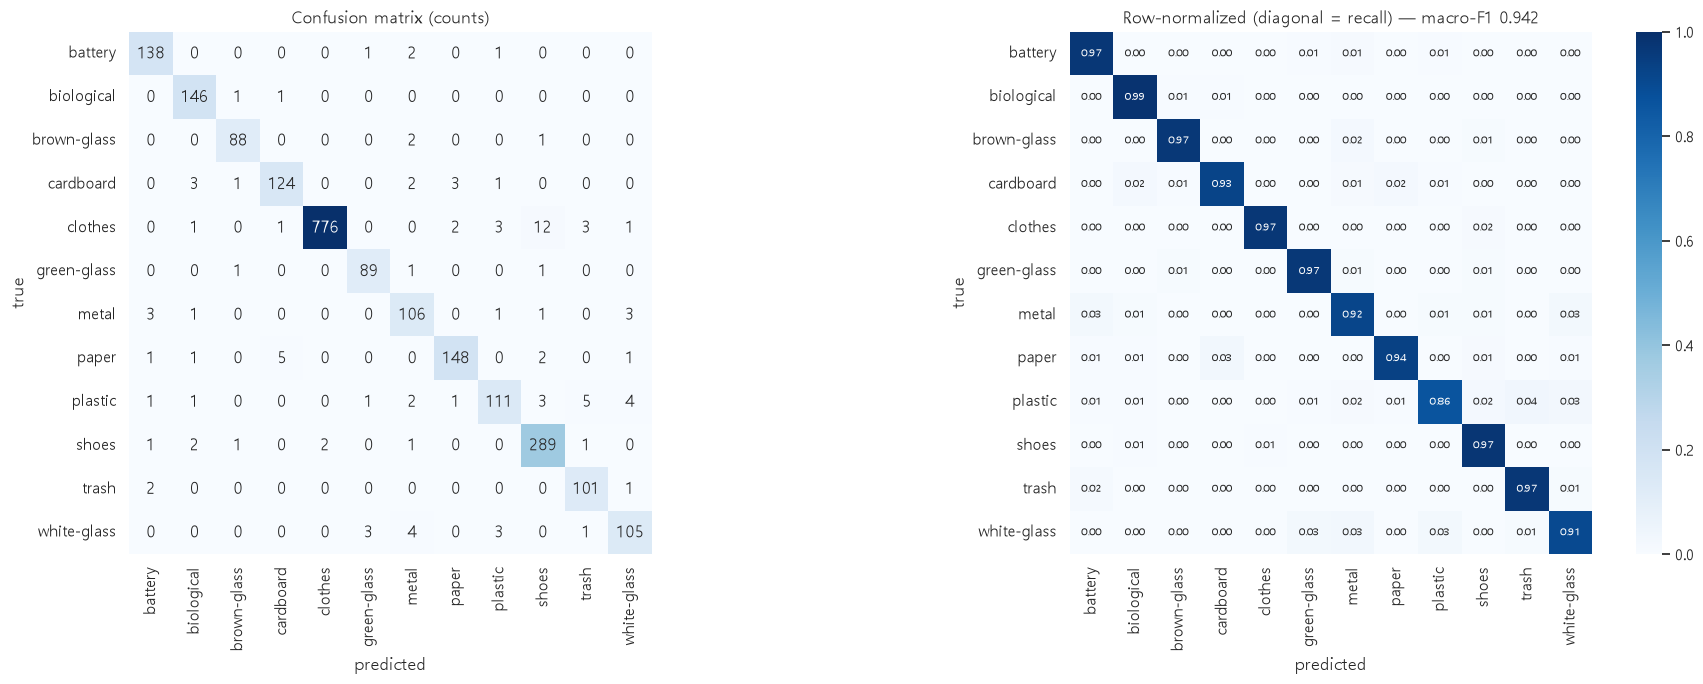

In [6]:
cm  = confusion_matrix(y_true, y_pred, labels=range(N_CLASSES))
cmn = cm / cm.sum(axis=1, keepdims=True)     # 행 정규화 → 대각선 = recall

fig, axes = plt.subplots(1, 2, figsize=(19, 7))

sns.heatmap(cm, ax=axes[0], cmap="Blues", annot=True, fmt="d", square=True,
            xticklabels=classes, yticklabels=classes, cbar=False)
axes[0].set_title("Confusion matrix (counts)")

sns.heatmap(cmn, ax=axes[1], cmap="Blues", vmin=0, vmax=1, annot=True, fmt=".2f",
            square=True, xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 7})
axes[1].set_title(f"Row-normalized (diagonal = recall) — macro-F1 {test_macro_f1:.3f}")

for ax in axes:
    ax.set_xlabel("predicted"); ax.set_ylabel("true")

plt.tight_layout()
plt.savefig(OUT / "figures" / "15_test_confusion.png", dpi=150)
plt.show()

In [7]:
pairs = []
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if i != j and cm[i, j] > 0:
            pairs.append({"true": classes[i], "predicted": classes[j],
                          "count": int(cm[i, j]),
                          "pct_of_true": round(100 * cm[i, j] / cm[i].sum(), 1)})

pairs = pd.DataFrame(pairs).sort_values("count", ascending=False)
pairs.to_csv(OUT / "metrics" / "test_confusion_pairs.csv",
             index=False, encoding="utf-8")

print(f"전체 오분류 {int(cm.sum() - np.trace(cm))}건 / {len(y_true)}건 "
      f"({100 * (1 - np.trace(cm) / cm.sum()):.1f}%)")
print("\n상위 12개 혼동 쌍")
print(pairs.head(12).to_string(index=False))

전체 오분류 104건 / 2325건 (4.5%)

상위 12개 혼동 쌍
       true   predicted  count  pct_of_true
    clothes       shoes     12          1.5
      paper   cardboard      5          3.2
    plastic       trash      5          3.9
white-glass       metal      4          3.4
    plastic white-glass      4          3.1
  cardboard       paper      3          2.2
    plastic       shoes      3          2.3
      metal     battery      3          2.6
    clothes       trash      3          0.4
    clothes     plastic      3          0.4
      metal white-glass      3          2.6
  cardboard  biological      3          2.2


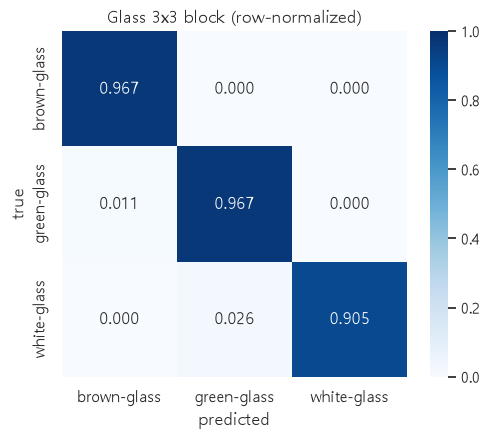

EDA 겹침 계수 vs 실제 상호 오분류
--------------------------------------------------------
brown-glass  <-> green-glass   겹침 0.146  |  상호 오분류   1건 (0.5%)
green-glass  <-> white-glass   겹침 0.202  |  상호 오분류   3건 (1.4%)
brown-glass  <-> white-glass   겹침 0.422  |  상호 오분류   0건 (0.0%)


In [8]:
glass_idx = [i for i, c in enumerate(classes) if "glass" in c]
glass_cls = [classes[i] for i in glass_idx]

sub  = cm[np.ix_(glass_idx, glass_idx)]
subn = sub / cm[glass_idx].sum(axis=1, keepdims=True)   # 분모는 전체 예측 기준

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(subn, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
            square=True, xticklabels=glass_cls, yticklabels=glass_cls, ax=ax)
ax.set_title("Glass 3x3 block (row-normalized)")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout()
plt.savefig(OUT / "figures" / "16_glass_block.png", dpi=150)
plt.show()

overlap_eda = {("brown-glass", "green-glass"): 0.146,
               ("green-glass", "white-glass"): 0.202,
               ("brown-glass", "white-glass"): 0.422}

print("EDA 겹침 계수 vs 실제 상호 오분류")
print("-" * 56)
for (a, b), ov in sorted(overlap_eda.items(), key=lambda kv: kv[1]):
    ia, ib = classes.index(a), classes.index(b)
    both = int(cm[ia, ib] + cm[ib, ia])
    denom = int(cm[ia].sum() + cm[ib].sum())
    print(f"{a:12s} <-> {b:12s}  겹침 {ov:.3f}  |  "
          f"상호 오분류 {both:3d}건 ({100 * both / denom:.1f}%)")

In [9]:
worst = per_class.iloc[0]["class"]
wi = classes.index(worst)

print(f"최저 F1 클래스: {worst} (F1 {per_class.iloc[0]['f1']:.3f}, "
      f"n={int(per_class.iloc[0]['n'])})")
print()
print(f"[{worst}]를 무엇으로 잘못 예측했나 (recall 손실)")
row = pd.DataFrame({"predicted": classes, "count": cm[wi]})
row = row[(row["count"] > 0) & (row["predicted"] != worst)].sort_values(
    "count", ascending=False)
row["pct"] = (100 * row["count"] / cm[wi].sum()).round(1)
print(row.to_string(index=False))

print()
print(f"무엇을 [{worst}]로 잘못 예측했나 (precision 손실)")
col = pd.DataFrame({"true": classes, "count": cm[:, wi]})
col = col[(col["count"] > 0) & (col["true"] != worst)].sort_values(
    "count", ascending=False)
col["pct"] = (100 * col["count"] / cm[:, wi].sum()).round(1)
print(col.to_string(index=False))

최저 F1 클래스: plastic (F1 0.892, n=129)

[plastic]를 무엇으로 잘못 예측했나 (recall 손실)
  predicted  count  pct
      trash      5  3.9
white-glass      4  3.1
      shoes      3  2.3
      metal      2  1.6
    battery      1  0.8
 biological      1  0.8
green-glass      1  0.8
      paper      1  0.8

무엇을 [plastic]로 잘못 예측했나 (precision 손실)
       true  count  pct
    clothes      3  2.5
white-glass      3  2.5
    battery      1  0.8
  cardboard      1  0.8
      metal      1  0.8


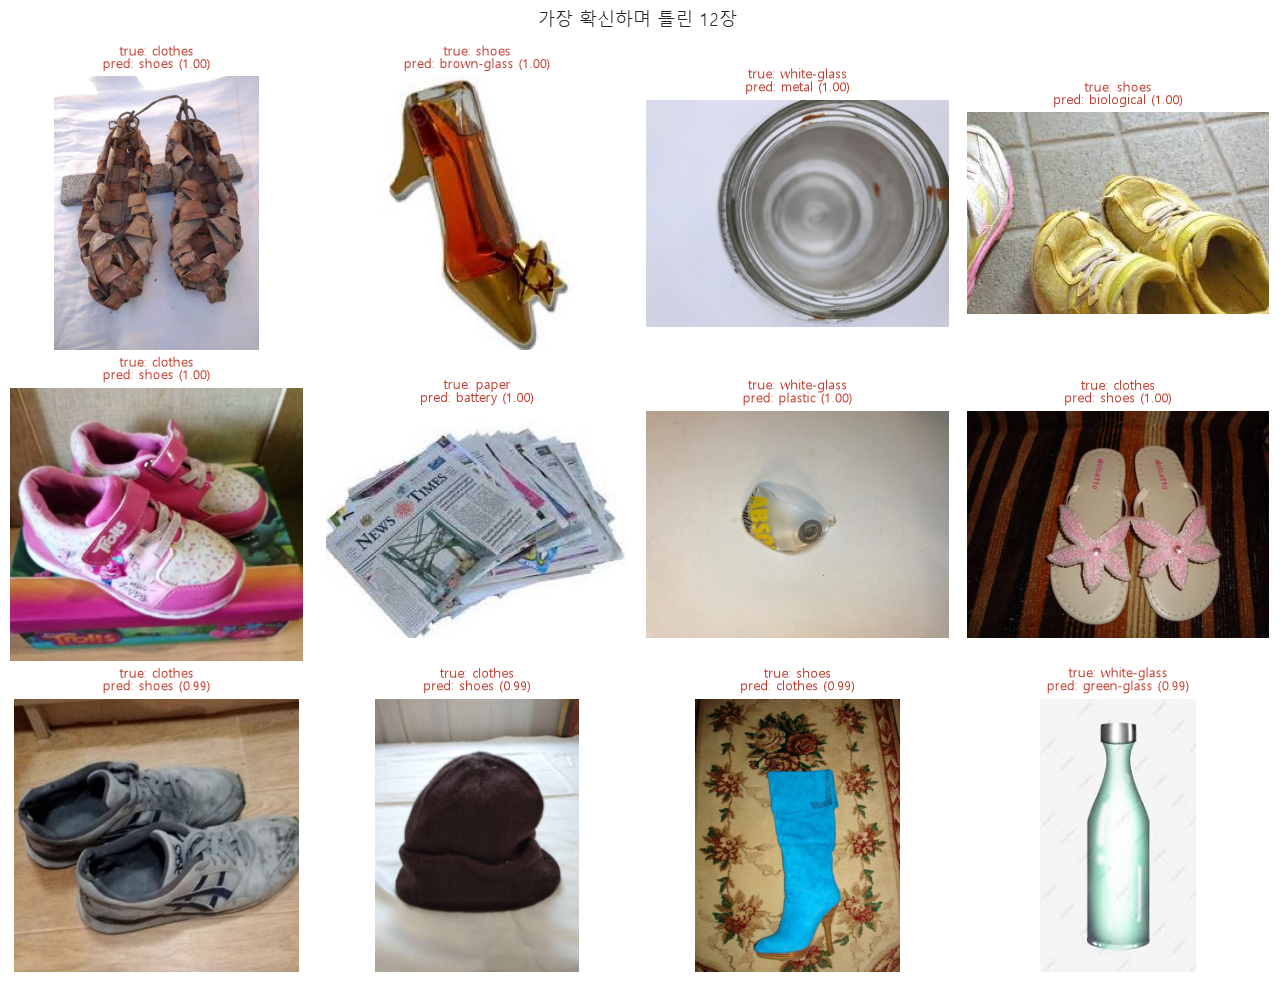

In [10]:
wrong = np.where(y_pred != y_true)[0]
order = wrong[np.argsort(-conf[wrong])]        # 확신하며 틀린 것부터

n_show = min(12, len(order))
fig, axes = plt.subplots(3, 4, figsize=(13, 10))

for ax, k in zip(axes.ravel(), order[:n_show]):
    ax.imshow(Image.open(test_df.loc[k, "path"]).convert("RGB"))
    ax.axis("off")
    ax.set_title(f"true: {classes[y_true[k]]}\npred: {classes[y_pred[k]]} "
                 f"({conf[k]:.2f})", fontsize=9, color="#c0392b")

for ax in axes.ravel()[n_show:]:
    ax.axis("off")

plt.suptitle("가장 확신하며 틀린 12장", fontsize=13)
plt.tight_layout()
plt.savefig(OUT / "figures" / "17_worst_errors.png", dpi=130)
plt.show()

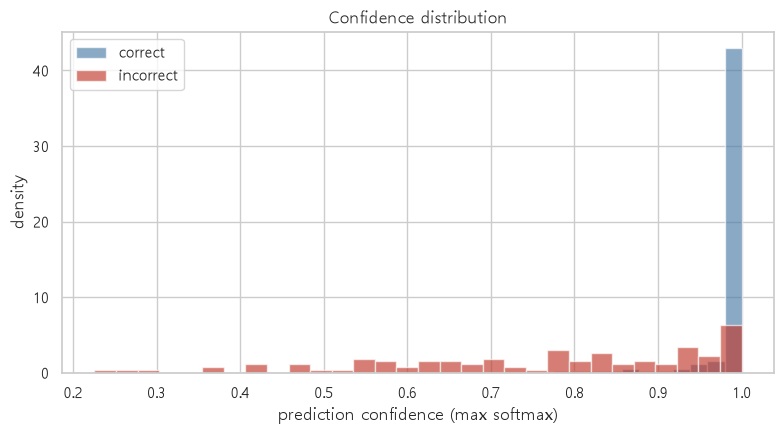

정답 평균 확신도 : 0.982
오답 평균 확신도 : 0.764
확신도 0.90 이상만 채택 시 — 커버리지  91.8%, 정확도 98.36%
확신도 0.95 이상만 채택 시 — 커버리지  89.0%, 정확도 98.94%
확신도 0.99 이상만 채택 시 — 커버리지  80.9%, 정확도 99.42%


In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(conf[y_pred == y_true], bins=30, alpha=0.65, label="correct",
        color="#4a7ba7", density=True)
ax.hist(conf[y_pred != y_true], bins=30, alpha=0.65, label="incorrect",
        color="#c0392b", density=True)
ax.set_xlabel("prediction confidence (max softmax)")
ax.set_ylabel("density")
ax.set_title("Confidence distribution")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "figures" / "18_confidence.png", dpi=150)
plt.show()

print(f"정답 평균 확신도 : {conf[y_pred == y_true].mean():.3f}")
print(f"오답 평균 확신도 : {conf[y_pred != y_true].mean():.3f}")

for t in [0.9, 0.95, 0.99]:
    keep = conf >= t
    if keep.sum():
        print(f"확신도 {t:.2f} 이상만 채택 시 — 커버리지 "
              f"{100 * keep.mean():5.1f}%, 정확도 "
              f"{100 * (y_pred[keep] == y_true[keep]).mean():.2f}%")

In [12]:
final = pd.read_csv(OUT / "metrics" / "transfer_comparison.csv")
final = final.rename(columns={"val_acc": "val_acc(%)"})

test_row = pd.DataFrame([{
    "model": "resnet18_finetune (TEST)",
    "val_acc(%)": round(test_acc, 2),
    "macro_f1": round(test_macro_f1, 4),
    "min_recall": round(float(rec.min()), 3),
    "worst_class": classes[int(rec.argmin())],
    "recall_std": round(float(rec.std()), 3),
    "minutes": np.nan,
}])

report = pd.concat([final, test_row], ignore_index=True)
report.to_csv(OUT / "metrics" / "final_report.csv", index=False, encoding="utf-8")
print(report.to_string(index=False))

summary = {
    "test_accuracy":    round(float(test_acc), 2),
    "test_macro_f1":    round(float(test_macro_f1), 4),
    "test_weighted_f1": round(float(test_w_f1), 4),
    "val_macro_f1":     round(float(ck["val_macro_f1"]), 4),
    "n_test":           int(len(y_true)),
    "n_errors":         int((y_pred != y_true).sum()),
    "best_class":       per_class.iloc[-1]["class"],
    "worst_class":      per_class.iloc[0]["class"],
    "top_confusion":    f"{pairs.iloc[0]['true']} -> {pairs.iloc[0]['predicted']} "
                        f"({int(pairs.iloc[0]['count'])}건)",
}
with open(OUT / "metrics" / "final_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print()
for k, v in summary.items():
    print(f"  {k:18s} {v}")

                   model  val_acc(%)  macro_f1  min_recall worst_class  recall_std  minutes
      GarbageCNN_scratch       61.14    0.5786       0.304       shoes       0.181      9.5
         resnet18_frozen       91.65    0.8841       0.608     plastic       0.106      9.9
       resnet18_finetune       95.14    0.9371       0.785     plastic       0.057     11.5
resnet18_finetune (TEST)       95.53    0.9421       0.860     plastic       0.036      NaN

  test_accuracy      95.53
  test_macro_f1      0.9421
  test_weighted_f1   0.9553
  val_macro_f1       0.9371
  n_test             2325
  n_errors           104
  best_class         clothes
  worst_class        plastic
  top_confusion      clothes -> shoes (12건)


In [13]:
print(classification_report(y_true, y_pred, target_names=classes,
                            digits=3, zero_division=0))

              precision    recall  f1-score   support

     battery      0.945     0.972     0.958       142
  biological      0.942     0.986     0.964       148
 brown-glass      0.957     0.967     0.962        91
   cardboard      0.947     0.925     0.936       134
     clothes      0.997     0.971     0.984       799
 green-glass      0.947     0.967     0.957        92
       metal      0.883     0.922     0.902       115
       paper      0.961     0.937     0.949       158
     plastic      0.925     0.860     0.892       129
       shoes      0.935     0.973     0.954       297
       trash      0.910     0.971     0.940       104
 white-glass      0.913     0.905     0.909       116

    accuracy                          0.955      2325
   macro avg      0.939     0.946     0.942      2325
weighted avg      0.956     0.955     0.955      2325



In [14]:
figs = sorted((OUT / "figures").glob("*.png"))
print(f"발표자료용 그림 {len(figs)}장 — {(OUT / 'figures').resolve()}")
for p in figs:
    print("  ", p.name)

발표자료용 그림 17장 — C:\Users\KDT-17\Documents\17-DeepLearning\outputs\garbage\figures
   01_class_dist.png
   02_resolution.png
   03_samples.png
   04_glass_hue.png
   05_glass_sat_val.png
   06_split.png
   07_recall_by_strategy.png
   08_curves.png
   09_confusion.png
   11_transfer_recall.png
   12_transfer_curves.png
   13_transfer_confusion.png
   14_test_per_class.png
   15_test_confusion.png
   16_glass_block.png
   17_worst_errors.png
   18_confidence.png
